# 서울시 도로구간 시각화 및 25m 포인트 생성

`(도로명주소)도로구간_서울/TL_SPRD_MANAGE_11_202605.shp`에서 서울시(`SIG_CD`가 `11`로 시작) 도로구간 중 도로 클래스 `3: 로`, `4: 길`만 추출해 단색으로 시각화하고, 도로 라인 위에 25m 간격 포인트를 생성합니다.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt

SRC_DIR = Path.cwd() / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from silverwalk.accidents import add_accident_risk
from silverwalk.business import add_business_category_counts
from silverwalk.config import (
    ACCIDENT_BUFFER_M,
    ACCIDENT_CSV,
    BUSINESS_CATEGORY_COLUMNS,
    BUSINESS_CSV,
    BUSINESS_RADIUS_M,
    NODELINK_SHP,
    OUTPUT_JOIN_CSV,
    POINT_INTERVAL_M,
    TARGET_REGION_NAME,
)
from silverwalk.features import make_base_point_df
from silverwalk.roads import (
    create_point_buffers,
    create_road_points,
    filter_target_roads,
    load_road_segments,
    make_road_summary,
)
from silverwalk.speed import add_speed_limit

# 한글 폰트가 설치된 환경에서는 한글 제목/범례가 정상 표시됩니다.
plt.rcParams["font.family"] = ["NanumGothic", "Malgun Gothic", "AppleGothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False


In [2]:
roads, ROAD_SHP = load_road_segments()

print(f"도로구간 파일: {ROAD_SHP}")
print(f"전체 도로구간 수: {len(roads):,}")
print(f"원본 좌표계: {roads.crs}")
display(roads.head())


도로구간 파일: Data/(도로명주소)도로구간_서울/TL_SPRD_MANAGE_11_202605.shp
전체 도로구간 수: 66,689
원본 좌표계: EPSG:5179


,ALWNC_DE,ALWNC_RESN,BSI_INT,ENG_RN,MVMN_DE,MVMN_RESN,MVM_RES_CD,NTFC_DE,OPERT_DE,RBP_CN,...,RDS_MAN_NO,REP_CN,RN,RN_CD,ROAD_BT,ROAD_LT,ROA_CLS_SE,SIG_CD,WDR_RD_CD,geometry
0,20100628,명륜길 일련번호 부여,10,Myeongnyun 10-gil,None,"광역도로 정비 및 부여사유, 부여방식 정비",90,20100702,20141030214859,명륜3가 1-352,...,1,명륜3가 53-21,명륜10길,4100077,5.0,304.0,4,11110,3,"LINESTRING (955228.522 1954751.951, 955222.399..."
1,20100628,성균관로 일련번호 부여,10,Sungkyunkwan-ro 13-gil,None,"광역도로 정비 및 부여사유, 부여방식 정비",90,20100702,20141030214859,명륜3가 1-1198,...,2,명륜3가 1-352,성균관로13길,4100165,6.0,25.0,4,11110,3,"LINESTRING (955379.909 1954756.643, 955363.184..."
2,20100628,성균관로 일련번호 부여,10,Sungkyunkwan-ro 15ga-gil,None,"광역도로 정비 및 부여사유, 부여방식 정비",90,20100702,20141030214859,명륜1가 5-27,...,3,명륜1가 7-101,성균관로15가길,4100167,4.0,39.0,4,11110,3,"LINESTRING (955603.993 1954638.552, 955593.742..."
3,20100628,조선시대 성균관 유생들의 여가를 즐기던 거리 명칭 인용,10,Daemyeong-gil,None,"광역도로 정비 및 부여사유, 부여방식 정비",90,20100702,20141030214657,혜화동 142-1,...,4,명륜2가 181-4,대명길,4100032,7.0,258.0,4,11110,3,"LINESTRING (955997.301 1953942.912, 955971.691..."
4,20100419,도로구간에 위치한 창덕궁의 정문인 돈화문의 역사성 반영,10,Donhwamun-ro,None,"광역도로 정비 및 부여사유, 부여방식 정비",90,20100422,20141030214829,묘동 20-5,...,5,묘동 20-4,돈화문로,3100003,1.0,28.0,3,11110,3,"LINESTRING (955117.972 1952634.429, 955145.231..."


In [3]:
target_all_roads, target_roads = filter_target_roads(roads)
summary = make_road_summary(target_all_roads, target_roads)

display(summary)
display(target_roads["ROA_CLS_SE"].value_counts().sort_index().rename("도로 클래스별 구간 수"))
display(target_roads[["SIG_CD", "RN", "RN_CD", "ROAD_LT", "ROAD_BT", "ROA_CLS_SE", "geometry"]].head())


,항목,값
0,시각화 대상 도로구간 수,"66,151"
1,전체 서울시 도로구간 수,"66,689"
2,총 연장(km),"38,031.8"
3,평균 도로폭(m),5.0
4,좌표계,EPSG:5179


ROA_CLS_SE
3     8503
4    57648
Name: 도로 클래스별 구간 수, dtype: int64

,SIG_CD,RN,RN_CD,ROAD_LT,ROAD_BT,ROA_CLS_SE,geometry
0,11110,명륜10길,4100077,304.0,5.0,4,"LINESTRING (955228.522 1954751.951, 955222.399..."
1,11110,성균관로13길,4100165,25.0,6.0,4,"LINESTRING (955379.909 1954756.643, 955363.184..."
2,11110,성균관로15가길,4100167,39.0,4.0,4,"LINESTRING (955603.993 1954638.552, 955593.742..."
3,11110,대명길,4100032,258.0,7.0,4,"LINESTRING (955997.301 1953942.912, 955971.691..."
4,11110,돈화문로,3100003,28.0,1.0,3,"LINESTRING (955117.972 1952634.429, 955145.231..."


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.

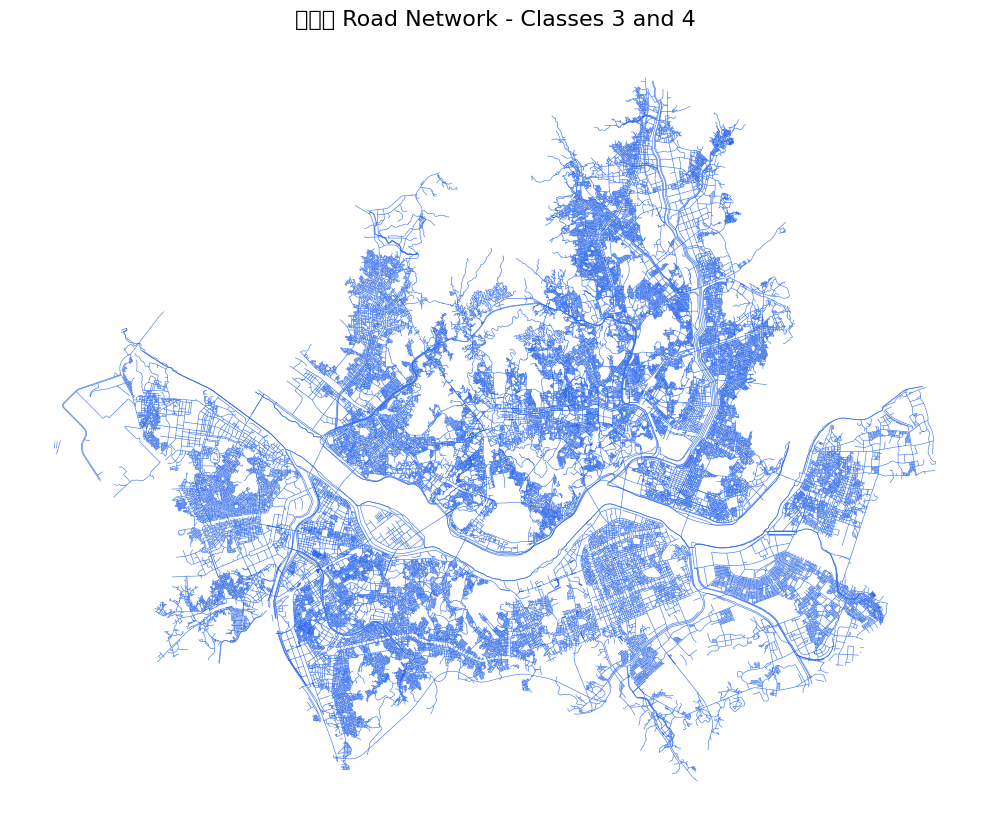

In [4]:
fig, ax = plt.subplots(figsize=(10, 10))

target_roads.plot(
    ax=ax,
    linewidth=0.45,
    color="#2563eb",
    alpha=0.85,
)

ax.set_title(f"{TARGET_REGION_NAME} Road Network - Classes 3 and 4", fontsize=16, pad=12)
ax.set_axis_off()
ax.set_aspect("equal")

plt.tight_layout()
plt.show()


## 서울시 도로 25m 간격 포인트 생성

현재 도로 데이터 좌표계는 EPSG:5179이므로 거리 단위는 미터입니다. 아래 코드는 도로 클래스 `3: 로`, `4: 길` 라인 위에 25m 간격 포인트를 생성합니다.


In [5]:
points_25m_gdf = create_road_points(target_roads, distance=POINT_INTERVAL_M)

print(f"생성된 25m 간격 포인트 수: {len(points_25m_gdf):,}")
display(points_25m_gdf.head())


생성된 25m 간격 포인트 수: 450,663


,POINT_ID,ROAD_IDX,POINT_SEQ,RN,RN_CD,ROAD_LT,ROAD_BT,ROA_CLS_SE,geometry
0,0,0,0,명륜10길,4100077,304.0,5.0,4,POINT (955228.522 1954751.951)
1,1,0,1,명륜10길,4100077,304.0,5.0,4,POINT (955206.65 1954741.134)
2,2,0,2,명륜10길,4100077,304.0,5.0,4,POINT (955189.328 1954723.282)
3,3,0,3,명륜10길,4100077,304.0,5.0,4,POINT (955171.912 1954705.586)
4,4,0,4,명륜10길,4100077,304.0,5.0,4,POINT (955155.168 1954687.123)


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.

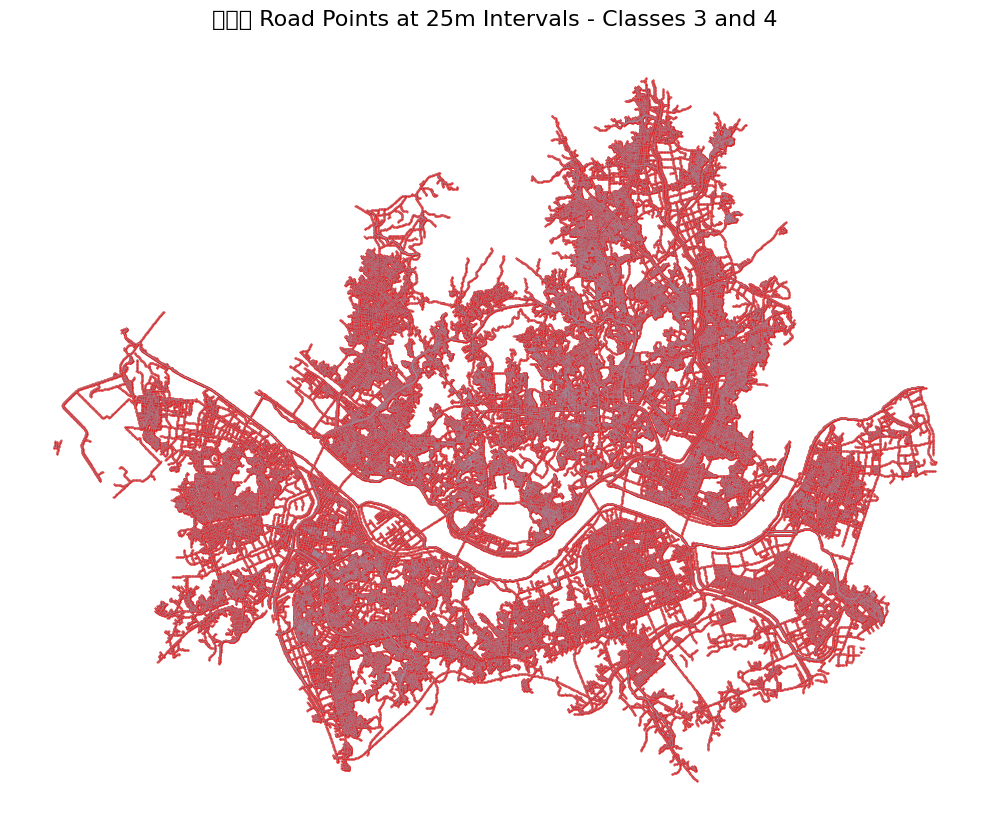

In [6]:
fig, ax = plt.subplots(figsize=(10, 10))

target_roads.plot(
    ax=ax,
    linewidth=0.35,
    color="#94a3b8",
    alpha=0.7,
)

points_25m_gdf.plot(
    ax=ax,
    markersize=0.25,
    color="#dc2626",
    alpha=0.75,
)

ax.set_title(f"{TARGET_REGION_NAME} Road Points at 25m Intervals - Classes 3 and 4", fontsize=16, pad=12)
ax.set_axis_off()
ax.set_aspect("equal")

plt.tight_layout()
plt.show()


## 25m 포인트별 50m 버퍼 생성

`points_25m_gdf`의 각 포인트를 중심으로 반경 50m 버퍼를 생성합니다. EPSG:5179 좌표계는 미터 단위이므로 `buffer(50)`을 사용합니다.

In [7]:
point_buffers_50m_gdf = create_point_buffers(points_25m_gdf, buffer_distance_m=ACCIDENT_BUFFER_M)

print(f"생성된 50m 버퍼 수: {len(point_buffers_50m_gdf):,}")
display(point_buffers_50m_gdf.head())


생성된 50m 버퍼 수: 450,663


,POINT_ID,ROAD_IDX,POINT_SEQ,RN,RN_CD,ROAD_LT,ROAD_BT,ROA_CLS_SE,geometry
0,0,0,0,명륜10길,4100077,304.0,5.0,4,"POLYGON ((955278.522 1954751.951, 955278.281 1..."
1,1,0,1,명륜10길,4100077,304.0,5.0,4,"POLYGON ((955256.65 1954741.134, 955256.409 19..."
2,2,0,2,명륜10길,4100077,304.0,5.0,4,"POLYGON ((955239.328 1954723.282, 955239.087 1..."
3,3,0,3,명륜10길,4100077,304.0,5.0,4,"POLYGON ((955221.912 1954705.586, 955221.671 1..."
4,4,0,4,명륜10길,4100077,304.0,5.0,4,"POLYGON ((955205.168 1954687.123, 955204.928 1..."


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.

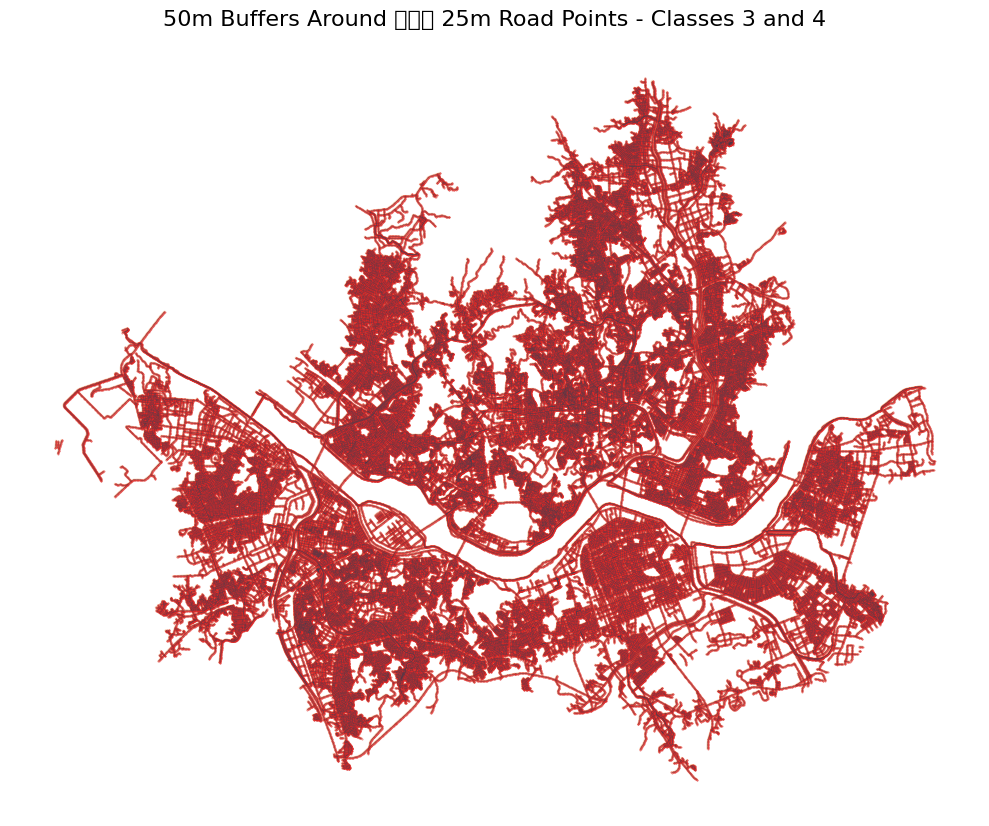

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))

point_buffers_50m_gdf.plot(
    ax=ax,
    color="#f97316",
    alpha=0.12,
    edgecolor="none",
)

target_roads.plot(
    ax=ax,
    linewidth=0.25,
    color="#334155",
    alpha=0.75,
)

points_25m_gdf.plot(
    ax=ax,
    markersize=0.15,
    color="#dc2626",
    alpha=0.6,
)

ax.set_title(f"50m Buffers Around {TARGET_REGION_NAME} 25m Road Points - Classes 3 and 4", fontsize=16, pad=12)
ax.set_axis_off()
ax.set_aspect("equal")

plt.tight_layout()
plt.show()


## Feature 추가 함수

Feature 추가 함수는 `src/silverwalk/` 모듈로 분리했습니다. 이 노트북에서는 결합 순서만 실행합니다.


In [9]:
print(f"상가 업종 컬럼 수: {len(BUSINESS_CATEGORY_COLUMNS):,}")
print(f"사고 데이터: {ACCIDENT_CSV}")
print(f"ITS 표준노드링크: {NODELINK_SHP}")
print(f"상가 정보: {BUSINESS_CSV}")


상가 업종 컬럼 수: 85
사고 데이터: Data/seoul_old_pedestrian_individual_accidents_2020_2025.csv
ITS 표준노드링크: Data/ITS_node_link/MOCT_LINK.shp
상가 정보: Data/소상공인시장진흥공단_상가(상권)정보_서울_202603.csv


## 최종 CSV 생성 및 저장

기본 포인트 데이터에 feature 추가 함수들을 순서대로 실행한 뒤 CSV로 저장합니다.

In [10]:
# 25m 포인트
final_join_df = make_base_point_df(points_25m_gdf)

# 위험도 컬럼 추가
final_join_df = add_accident_risk(
    final_df=final_join_df,
    points_gdf=points_25m_gdf,
    point_buffers_gdf=point_buffers_50m_gdf,
    accident_csv=ACCIDENT_CSV,
)

# 제한속도 컬럼 추가
final_join_df = add_speed_limit(
    final_df=final_join_df,
    points_gdf=points_25m_gdf,
    nodelink_shp=NODELINK_SHP,
)

# 반경 300m 업종별 상가 수 컬럼 추가
final_join_df = add_business_category_counts(
    final_df=final_join_df,
    points_gdf=points_25m_gdf,
    business_csv=BUSINESS_CSV,
    radius_m=BUSINESS_RADIUS_M,
)

# 마무리
final_join_df = final_join_df[["POINT_ID", "위도", "경도", "제한속도", "위험도"] + BUSINESS_CATEGORY_COLUMNS]

OUTPUT_JOIN_CSV.parent.mkdir(parents=True, exist_ok=True)
final_join_df.to_csv(OUTPUT_JOIN_CSV, index=False, encoding="utf-8-sig")

print(f"저장된 최종 데이터 행 수: {len(final_join_df):,}")
print(f"제한속도 결측 수: {final_join_df['제한속도'].isna().sum():,}")
print(f"상가 업종 컬럼 수: {len(BUSINESS_CATEGORY_COLUMNS):,}")
print(f"CSV 저장: {OUTPUT_JOIN_CSV}")
display(final_join_df.head())


사고 데이터 수: 11,369
버퍼 안에 포함된 사고-포인트 매칭 수: 140,952
제한속도 결합 대상 링크 수: 100,924
서울시 상가 데이터 수: 537,489
반경 300m 상가-포인트 매칭 수: 194,258,254
저장된 최종 데이터 행 수: 450,663
제한속도 결측 수: 0
상가 업종 컬럼 수: 85
CSV 저장: Data/seoul_road_points.csv


,POINT_ID,위도,경도,제한속도,위험도,과학·기술,교육,보건의료,부동산,소매,...,음식_구내식당·뷔페,음식_기타 간이,음식_기타 외국,음식_동남아시아,음식_비알코올,음식_서양식,음식_일식,음식_주점,음식_중식,음식_한식
0,0,37.591080,126.992864,10,0.0,20,5,0,0,15,...,2,7,0,1,8,1,2,0,1,12
1,1,37.590982,126.992616,10,0.0,19,5,0,0,14,...,2,6,0,1,7,1,2,0,0,10
2,2,37.590820,126.992421,10,0.0,15,5,0,0,12,...,2,6,0,1,6,1,2,0,0,10
3,3,37.590660,126.992225,10,0.0,14,4,0,0,12,...,1,6,0,1,6,1,2,0,0,10
4,4,37.590492,126.992037,10,0.0,14,2,0,0,12,...,1,6,0,1,6,1,2,0,0,10
